# Single Session Prediction

Only consider a single session in isolation. Use zero-shot inductive biases that Chronos 2 has, but probably not that good for our challenge.

### Read a session data

In [18]:
import pandas as pd

# Read the seen and unseen data
train_seen = pd.read_parquet("../data/bars_seen_train.parquet")
train_unseen = pd.read_parquet("../data/bars_unseen_train.parquet")

# Bring in sentiment data
sentiment_df = pd.read_csv("../sentiment_overview.csv")

train_seen = train_seen.merge(sentiment_df, on=['session', 'bar_ix'], how='left')
train_unseen = train_unseen.merge(sentiment_df, on=['session', 'bar_ix'], how='left')

# Have to infill missing data 
train_seen['linear_score'] = train_seen['linear_score'].fillna(0.0)
train_seen['polarity_score'] = train_seen['polarity_score'].fillna(0.0)

train_unseen['linear_score'] = train_unseen['linear_score'].fillna(0.0)
train_unseen['polarity_score'] = train_unseen['polarity_score'].fillna(0.0)

# Drop some sentiment columns (might re-add later)
cols_to_drop = ["headline", "decided_label", "prob_positive", "prob_negative", "prob_neutral", "cluster"]
train_seen = train_seen.drop(columns=cols_to_drop)
train_unseen = train_unseen.drop(columns=cols_to_drop)

train_seen = train_seen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)
train_unseen = train_unseen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)

# Already set the timestamps
start_date = pd.to_datetime('2000-01-01')

train_seen['timestamp'] = start_date + pd.to_timedelta(train_seen['bar_ix'], unit='D')
train_unseen['timestamp'] = start_date + pd.to_timedelta(train_unseen['bar_ix'], unit='D')


display(train_seen)
display(train_unseen)



,bar_ix,session,open,high,low,close,linear_score,polarity_score,timestamp
0,0,0,1.0000,1.0029,0.9986,0.9999,0.000000,0.000000,2000-01-01
1,1,0,0.9997,1.0040,0.9991,1.0033,0.000000,0.000000,2000-01-02
2,2,0,1.0034,1.0040,1.0015,1.0028,0.000000,0.000000,2000-01-03
3,3,0,1.0023,1.0059,1.0021,1.0056,0.000000,0.000000,2000-01-04
4,4,0,1.0057,1.0067,1.0043,1.0048,0.000000,0.000000,2000-01-05
...,...,...,...,...,...,...,...,...,...
49995,45,999,1.0119,1.0137,1.0101,1.0135,-0.958507,-0.984843,2000-02-15
49996,46,999,1.0136,1.0143,1.0113,1.0138,0.000000,0.000000,2000-02-16
49997,47,999,1.0130,1.0139,1.0113,1.0131,0.000000,0.000000,2000-02-17
49998,48,999,1.0134,1.0151,1.0125,1.0138,0.000000,0.000000,2000-02-18


,bar_ix,session,open,high,low,close,linear_score,polarity_score,timestamp
0,50,0,1.0318,1.0375,1.0318,1.0367,0.0,0.0,2000-02-20
1,51,0,1.0363,1.0377,1.0351,1.0351,0.0,0.0,2000-02-21
2,52,0,1.0353,1.0366,1.0338,1.0342,0.0,0.0,2000-02-22
3,53,0,1.0341,1.0376,1.0339,1.0373,0.0,0.0,2000-02-23
4,54,0,1.0375,1.0413,1.0371,1.0408,0.0,0.0,2000-02-24
...,...,...,...,...,...,...,...,...,...
49995,95,999,1.0229,1.0268,1.0217,1.0264,0.0,0.0,2000-04-05
49996,96,999,1.0262,1.0302,1.0262,1.0297,0.0,0.0,2000-04-06
49997,97,999,1.0295,1.0309,1.0277,1.0299,0.0,0.0,2000-04-07
49998,98,999,1.0301,1.0331,1.0284,1.0326,0.0,0.0,2000-04-08


### Predict with Chronos 2

In [25]:
import pandas as pd  # requires: pip install 'pandas[pyarrow]'
from chronos import Chronos2Pipeline

def predict_session(SESSION_ID: int, seen=train_seen, unseen=train_unseen):
    # Prepare the session
    seen = seen[seen["session"] == SESSION_ID]
    unseen = unseen[unseen["session"] == SESSION_ID]

    pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")

    pred_df = pipeline.predict_df(
        seen,
        future_df=None,
        prediction_length=50,  # Number of steps to forecast
        quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
        id_column="session",  # Column identifying different time series
        timestamp_column="timestamp",  # Column with datetime information
        target=["open", "high", "low", "close", "linear_score", "polarity_score"],  # Column(s) with time series values to predict
        cross_learning=True,
        batch_size=100
    )

    import matplotlib.pyplot as plt  # requires: pip install matplotlib

    ts_context = seen.set_index("timestamp")["close"]
    ts_pred = pred_df[pred_df["target_name"] == "close"].set_index("timestamp")
    ts_ground_truth = unseen.set_index("timestamp")["close"]

    ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
    ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
    ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
    plt.fill_between(
        ts_pred.index,
        ts_pred["0.1"],
        ts_pred["0.9"],
        alpha=0.7,
        label="prediction interval",
        color="xkcd:light lavender",
    )
    plt.legend()
    plt.show()

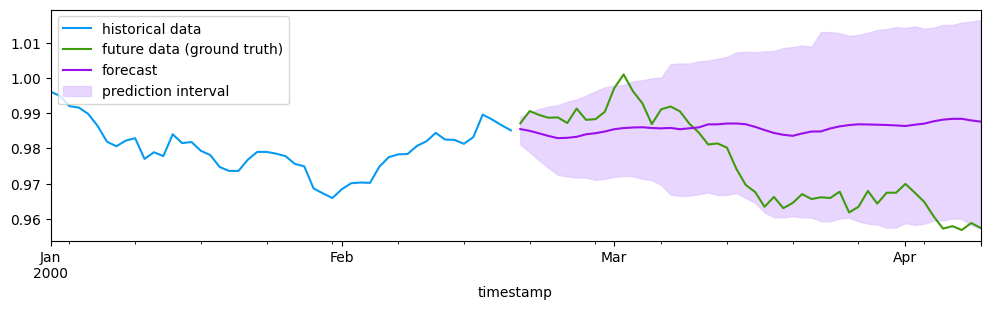

In [33]:
predict_session(SESSION_ID=124)

# Predict entire sequence

Take the entire group of time-series in context when predicting.

In [51]:

pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")

SLIDING_WINDOW_SIZE = 5 
TOTAL_FORECAST_STEPS = 50
all_pred_df = pd.DataFrame()

all_pred_df = pipeline.predict_df(
    train_seen,
    future_df=None,
    prediction_length=50,  # Number of steps to forecast
    quantile_levels=[0.1, 0.5, 0.9],  # Quantile for probabilistic forecast
    id_column="session",  # Column identifying different time series
    timestamp_column="timestamp",  # Column with datetime information
    target=["open", "high", "low", "close", "linear_score", "polarity_score"],  # Column(s) with time series values to predict
    cross_learning=True,
    batch_size=100
)



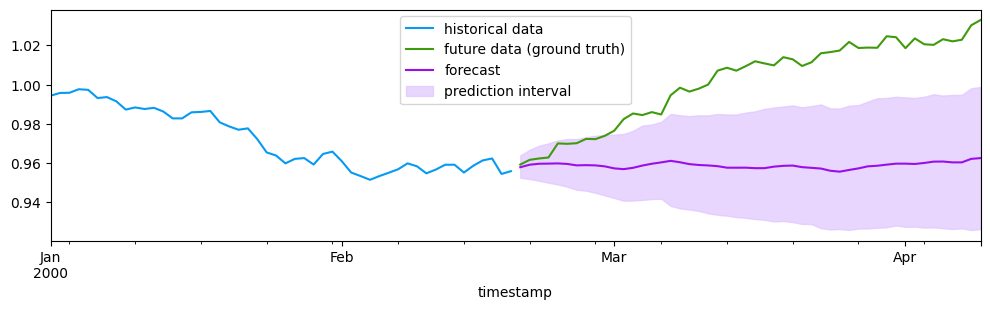

In [54]:
import matplotlib.pyplot as plt

DISPLAY_SESSION_ID = 129

display_seen = train_seen[train_seen["session"] == DISPLAY_SESSION_ID]
display_unseen = train_unseen[train_unseen["session"] == DISPLAY_SESSION_ID]
display_all_pred_df = all_pred_df[all_pred_df["session"] == DISPLAY_SESSION_ID]

ts_context = display_seen.set_index("timestamp")["close"]
ts_pred = display_all_pred_df[display_all_pred_df["target_name"] == "close"].set_index("timestamp")
ts_ground_truth = display_unseen.set_index("timestamp")["close"]

ts_context.plot(label="historical data", color="xkcd:azure", figsize=(12, 3))
ts_ground_truth.plot(label="future data (ground truth)", color="xkcd:grass green")
ts_pred["predictions"].plot(label="forecast", color="xkcd:violet")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"],
    ts_pred["0.9"],
    alpha=0.7,
    label="prediction interval",
    color="xkcd:light lavender",
)
plt.legend()
plt.show()

## Convert to a submission

In [58]:
import numpy as np

# Close at bar 49 (halfway) for each session
close_halfway = train_seen.groupby('session')['close'].last().rename('close_halfway')

# At bar 99: median prediction and CI bounds (q10, q90) for each session
pred_last = all_pred_df.groupby('session').last()[['predictions', '0.1', '0.9']]
pred_last.columns = ['pred_close_end', 'q10_end', 'q90_end']

# At bar 49 + SLIDING_WINDOW = most accurate estimate of uncertainty, since the rest are biased by passed predictions of the model
# first_pred_mid = all_pred_df.groupby('session').nth(SLIDING_WINDOW_SIZE-1)[['predictions', '0.1', '0.9']]
# display(first_pred_mid)
# first_pred_mid.columns = ['pred_close_first_pred', 'q10_first_pred', 'q90_first_pred']

submission_df = close_halfway.to_frame().join(pred_last)#.join(first_pred_mid)

EPSILON = 0.00  # minimum predicted return to trade (0.2%)
EPSILON_LONG = EPSILON
EPSILON_SHORT =  EPSILON  # Maintaining your asymmetric threshold
VARIANCE_THRESHOLD = 2
MAX_POSITION = 1.0           # Cap to prevent extreme leverage
CI_FLOOR = 1e-4              # Prevents division by zero or extreme signals

# 1. Calculate returns and uncertainty
# print(submission_df['q90_first_pred'])
# print(submission_df['q10_first_pred'])
submission_df['predicted_return'] = (submission_df['pred_close_end'] / submission_df['close_halfway']) - 1
submission_df['ci_width'] = (submission_df['q90_end'] - submission_df['q10_end']) / submission_df['close_halfway']

# 2. Calculate the raw signal
# We use np.maximum to ensure we never divide by zero or a sub-atomic CI width
submission_df['signal'] = submission_df['predicted_return'] / submission_df['ci_width'].clip(lower=CI_FLOOR)
display(submission_df)
# 3. Define Entry Conditions
# Long if return > EPSILON; Short if return < -5 * EPSILON
long_condition = submission_df['predicted_return'] > EPSILON_LONG
short_condition = submission_df['predicted_return'] < -EPSILON_SHORT
# variance_small = submission_df['ci_width'] < VARIANCE_THRESHOLD

# 4. Generate Target Position and Clip
# Apply signal where conditions are met, otherwise 0.0
submission_df['target_position'] = np.where(
    (long_condition),
    submission_df['signal'],
    0.0
)

# 5. Final Risk Overlay
# Ensure positions don't exceed your maximum allowed leverage/allocation
submission_df['target_position'] = submission_df['target_position'].clip(-MAX_POSITION, MAX_POSITION)


submission = submission_df[['target_position']].reset_index()[['session', 'target_position']].sort_values('session')
n_trading = (submission['target_position'] != 0).sum()
display(submission.head(10))
print(f"Trading {n_trading}/{len(submission)} sessions (epsilon={EPSILON})")

submission.describe()


,close_halfway,pred_close_end,q10_end,q90_end,predicted_return,ci_width,signal
session,,,,,,,
0,1.0316,-0.009630,-0.725860,0.456288,-1.009335,1.145936,-0.880795
1,1.0286,0.006247,-0.897956,0.982444,-0.993927,1.828116,-0.543689
2,1.0208,0.005271,-1.396107,1.288172,-0.994836,2.629584,-0.378325
3,1.0113,-0.011705,-0.605917,0.718970,-1.011574,1.310083,-0.772145
4,1.0280,-0.003633,-0.028337,0.037559,-1.003534,0.064101,-15.655533
...,...,...,...,...,...,...,...
995,0.9913,-0.001435,-0.095064,0.067825,-1.001448,0.164319,-6.094550
996,0.9915,-0.016554,-0.254521,0.150702,-1.016695,0.408697,-2.487654
997,0.9796,0.002724,-0.176769,0.144148,-0.997219,0.327600,-3.044013


,session,target_position
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0
5,5,0.0
6,6,0.0
7,7,0.0
8,8,0.0
9,9,0.0


Trading 0/1000 sessions (epsilon=0.0)


,session,target_position
count,1000.000000,1000.0
mean,499.500000,0.0
std,288.819436,0.0
min,0.000000,0.0
25%,249.750000,0.0
50%,499.500000,0.0
75%,749.250000,0.0
max,999.000000,0.0


## Compute Sharpe

/var/folders/1x/3yzs3rmd6bg8zvlc0df6zn_40000gn/T/ipykernel_19003/294544255.py:11: RuntimeWarning: invalid value encountered in scalar divide
  sharpe = np.mean(eval_df['pnl']) / np.std(eval_df['pnl']) * 16


Sharpe ratio on train (Chronos-2 median forecast): nan
Mean PnL: 0.000000
Std  PnL: 0.000000
Win rate: 0.00%


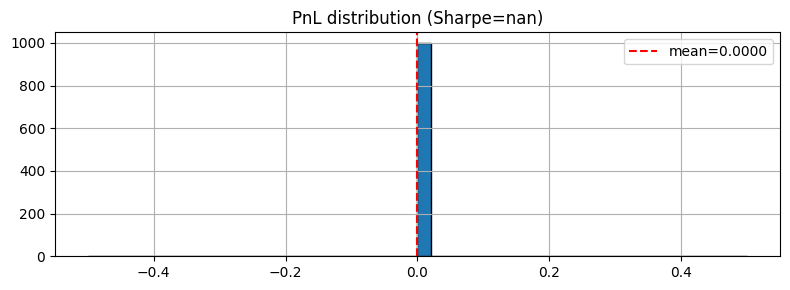

In [57]:
import numpy as np

# Actual close at bar 99 (end of session)
close_end = train_unseen.groupby('session')['close'].last().rename('close_end')

eval_df = submission.set_index('session').join(close_halfway).join(close_end)

# pnl_i = target_position_i * (close_end_i / close_halfway_i - 1)
eval_df['pnl'] = eval_df['target_position'] * (eval_df['close_end'] / eval_df['close_halfway'] - 1)

sharpe = np.mean(eval_df['pnl']) / np.std(eval_df['pnl']) * 16

print(f"Sharpe ratio on train (Chronos-2 median forecast): {sharpe:.4f}")
print(f"Mean PnL: {eval_df['pnl'].mean():.6f}")
print(f"Std  PnL: {eval_df['pnl'].std():.6f}")
print(f"Win rate: {(eval_df['pnl'] > 0).mean():.2%}")

import matplotlib.pyplot as plt
eval_df['pnl'].hist(bins=50, figsize=(8, 3), edgecolor='k')
plt.axvline(eval_df['pnl'].mean(), color='red', linestyle='--', label=f'mean={eval_df["pnl"].mean():.4f}')
plt.title(f'PnL distribution (Sharpe={sharpe:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# Submit submission on public and private data

In [ ]:
import pandas as pd

public_seen = pd.read_parquet("../data/bars_seen_public_test.parquet")
private_seen = pd.read_parquet("../data/bars_seen_private_test.parquet")

In [ ]:
import pandas as pd
import numpy as np
from chronos import Chronos2Pipeline

# PUBLIC DATASET
sentiment_df_pub = pd.read_csv("../anna/headline_stats_seen_pubtest.csv")
public_seen = public_seen.merge(sentiment_df_pub, on=['session', 'bar_ix'], how='left')
public_seen = public_seen.drop(columns=["headline"])
public_seen = public_seen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)

# PRIVATE DATASET
sentiment_df_priv = pd.read_csv("../anna/headline_stats_seen_privtest.csv")
private_seen = private_seen.merge(sentiment_df_priv, on=['session', 'bar_ix'], how='left')
private_seen = private_seen.drop(columns=["headline"])
private_seen = private_seen.groupby(['session', 'bar_ix']).sample(n=1, random_state=42).reset_index(drop=True)

start_date = pd.to_datetime('2000-01-01')
public_seen['timestamp'] = start_date + pd.to_timedelta(public_seen['bar_ix'], unit='D')
private_seen['timestamp'] = start_date + pd.to_timedelta(private_seen['bar_ix'], unit='D')

def make_submission(seen_df):
    pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="mps")
    
    EPSILON = 0

    pred_df = pipeline.predict_df(
        seen_df,
        future_df=None,
        prediction_length=50,
        quantile_levels=[0.1, 0.5, 0.9],
        id_column='session',
        timestamp_column='timestamp',
        target='close',
    )

    close_halfway = seen_df.groupby('session')['close'].last().rename('close_halfway')

    pred_last = pred_df.groupby('session').last()[['predictions', '0.1', '0.9']]
    pred_last.columns = ['pred_close_end', 'q10_end', 'q90_end']

    df = close_halfway.to_frame().join(pred_last)

    predicted_return = df['pred_close_end'] / df['close_halfway'] - 1
    ci_width = (df['q90_end'] - df['q10_end']) / df['close_halfway']
    signal = predicted_return / ci_width

    df['target_position'] = np.where(
        predicted_return > EPSILON,
        signal,
        0.0,
    )

    return df[['target_position']].reset_index()[['session', 'target_position']].sort_values('session')

print("Predicting public test sessions...")
public_submission = make_submission(public_seen)
print(f"  {len(public_submission)} sessions, IDs {public_submission['session'].min()}–{public_submission['session'].max()}")

print("Predicting private test sessions...")
private_submission = make_submission(private_seen)
print(f"  {len(private_submission)} sessions, IDs {private_submission['session'].min()}–{private_submission['session'].max()}")

final_submission = pd.concat([public_submission, private_submission], ignore_index=True)
final_submission.to_csv('submission_final.csv', index=False)
print(f"\nSaved submission_final.csv ({len(final_submission)} total rows)")
display(final_submission.head())
display(final_submission.tail())